# Unemployment Analysis with Python

Dataset: "Unemployment in India.csv"

importing necessary libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Loading Dataset

In [2]:
df = pd.read_csv("Unemployment in India.csv")

Dataset Inspection

In [3]:
df.shape

(768, 7)

In [4]:
df.head()       

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [6]:
df.describe() 

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [7]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [8]:
print(df.isnull().sum())

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [9]:
# Step 1: Stripping column names to remove leading/trailing spaces
df.columns = df.columns.str.strip()

# Step 2: Dropping rows with any missing values
df = df.dropna()

# Step 3: Reseting index after dropping
df = df.reset_index(drop=True)

# Step 4: Confirming missing values are removed
print(df.isnull().sum())
print(f"New dataset shape: {df.shape}")


Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64
New dataset shape: (740, 7)


In [10]:
duplicates = df[df.duplicated()]

# Step 2: Number of duplicate rows
print(f"Number of duplicate rows: {duplicates.shape[0]}")

# Step 3: Optional – view duplicate rows
print(duplicates)

Number of duplicate rows: 0
Empty DataFrame
Columns: [Region, Date, Frequency, Estimated Unemployment Rate (%), Estimated Employed, Estimated Labour Participation Rate (%), Area]
Index: []


In [11]:
print(df['Region'].unique())
print(df['Area'].value_counts())

['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Chandigarh']
Area
Urban    381
Rural    359
Name: count, dtype: int64


#### Dataset is Cleaned & Ready for Analysis

## Unemployment Analysis

C:\Users\sumai\AppData\Local\Temp\ipykernel_144\1008048581.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(ax=axes[0], x='Date', y='Estimated Unemployment Rate (%)', data=df, ci=None, color='blue')
C:\Users\sumai\AppData\Local\Temp\ipykernel_144\1008048581.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[3], x=avg_unemp.values, y=avg_unemp.index, palette="viridis")


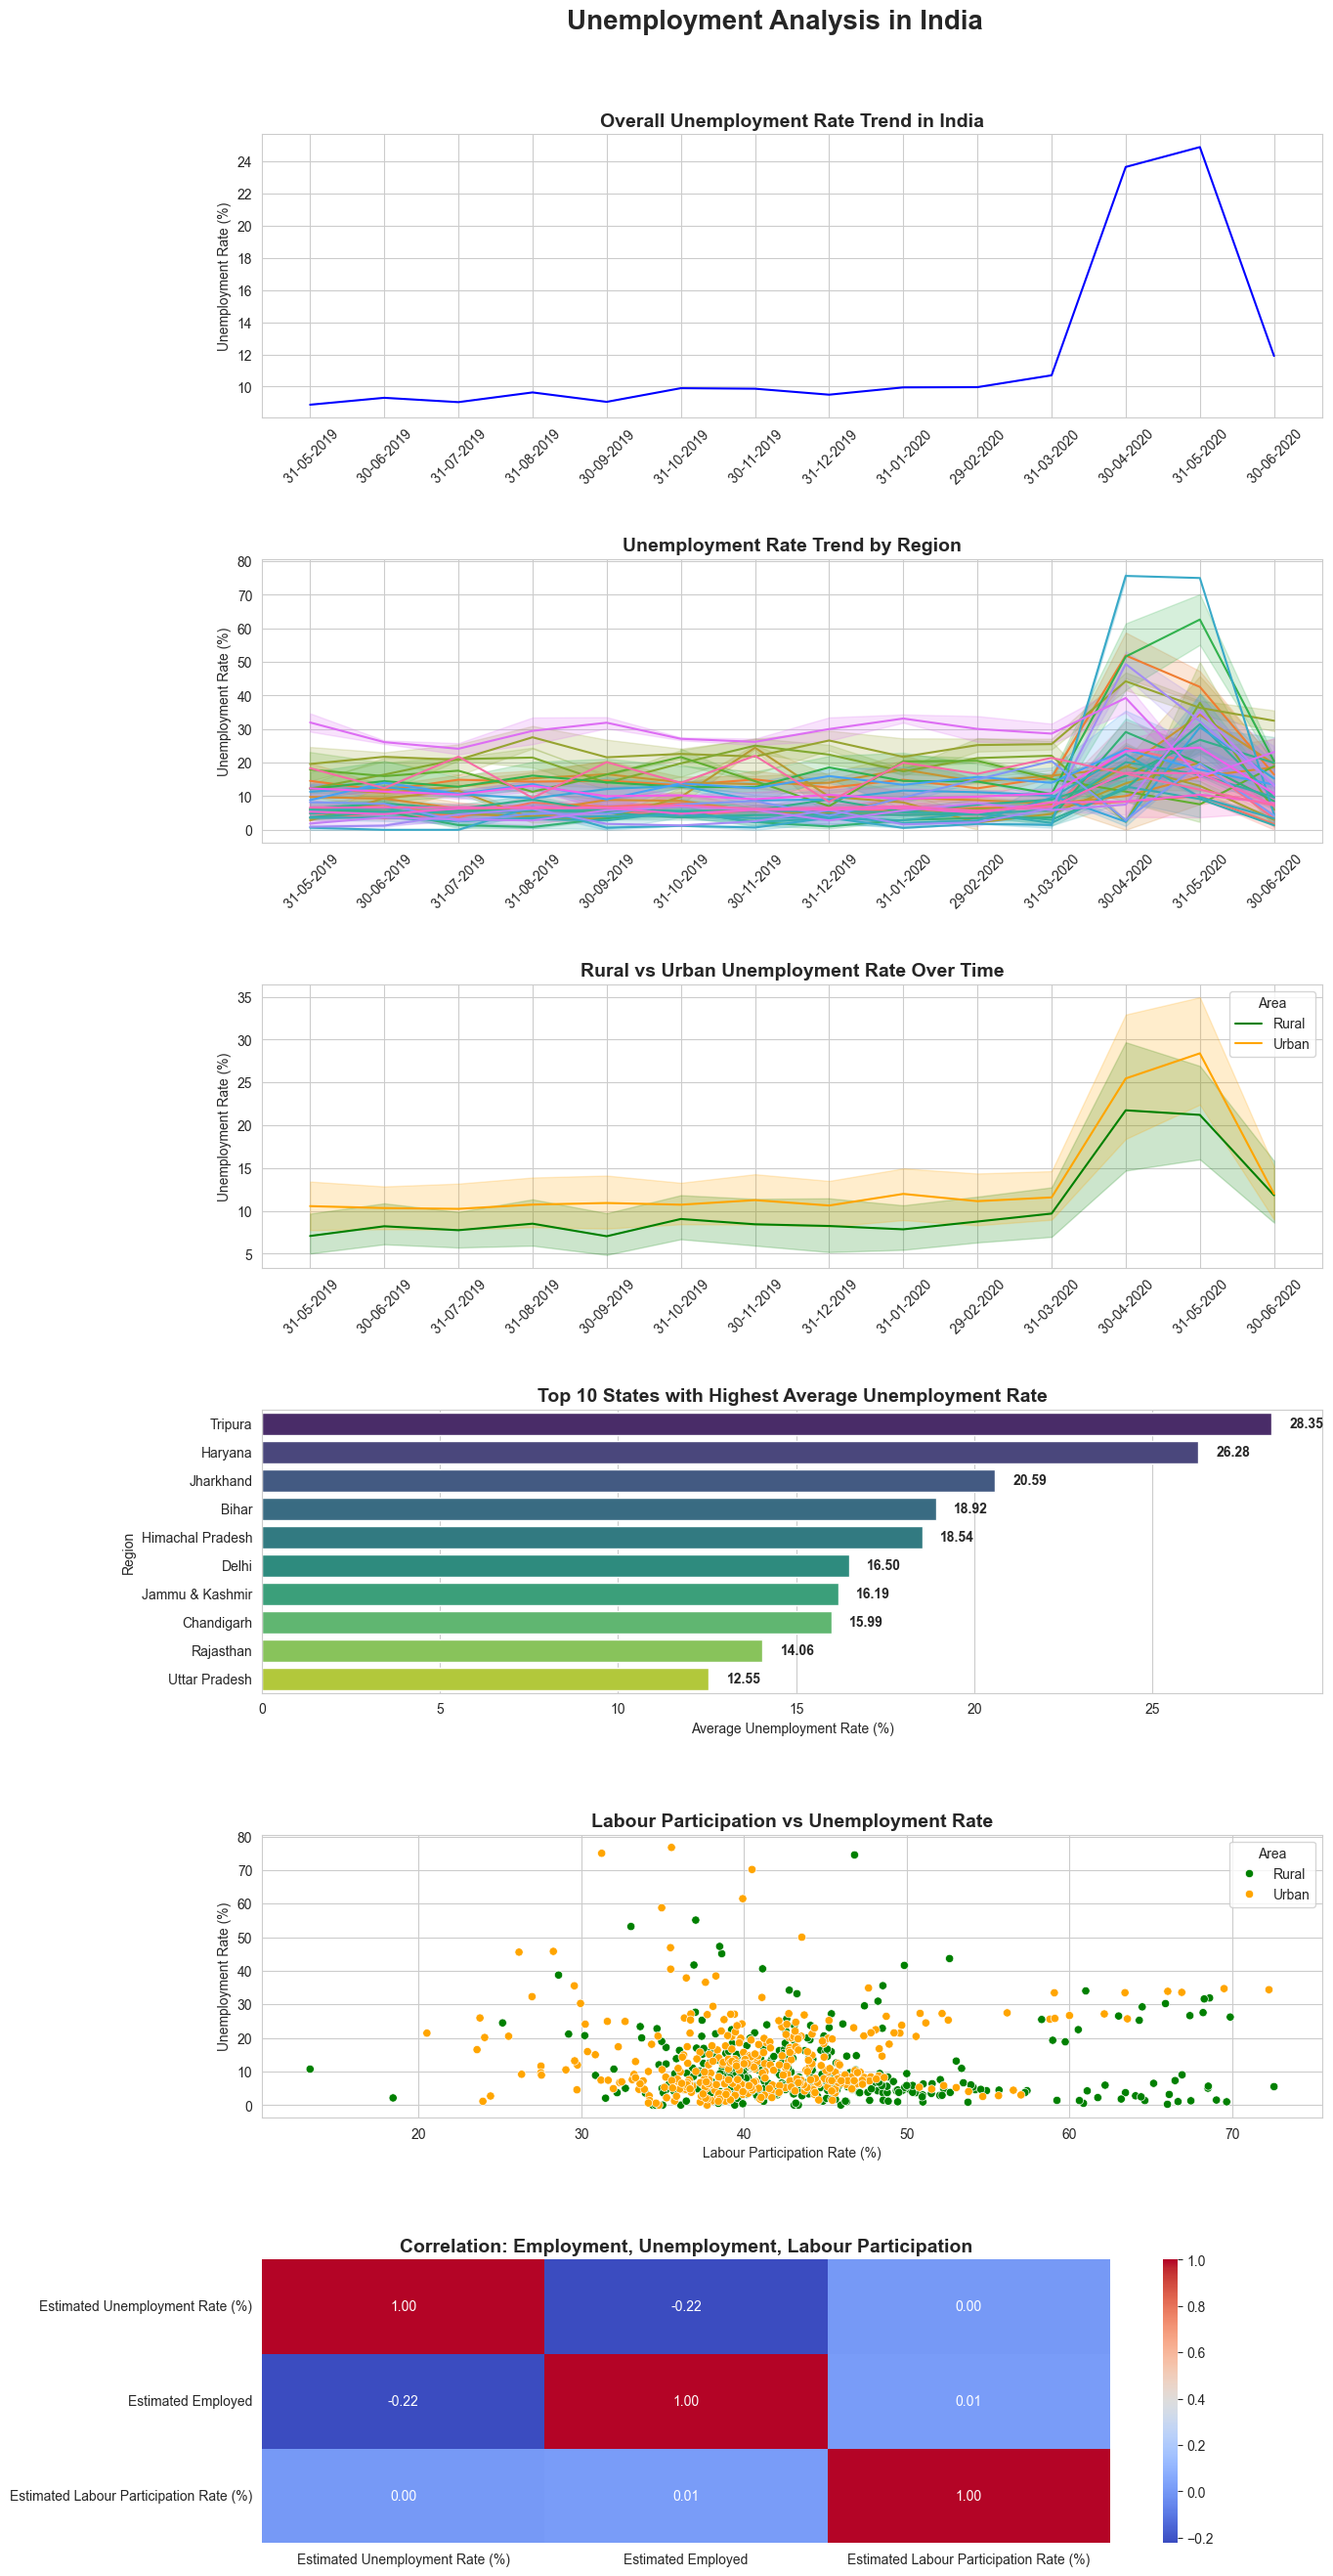

In [13]:
# Set Seaborn style
sns.set_style("whitegrid")

# Create 6x1 subplots
fig, axes = plt.subplots(6, 1, figsize=(14, 32))
plt.subplots_adjust(hspace=0.5)  # vertical spacing

# Add overall title
fig.suptitle("Unemployment Analysis in India", fontsize=20, fontweight='bold', y=0.92)

# 1️⃣ Overall Unemployment Trend
sns.lineplot(ax=axes[0], x='Date', y='Estimated Unemployment Rate (%)', data=df, ci=None, color='blue')
axes[0].set_title("Overall Unemployment Rate Trend in India", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Unemployment Rate (%)")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=45)

# 2️⃣ Unemployment Trend by Region
sns.lineplot(ax=axes[1], x='Date', y='Estimated Unemployment Rate (%)', hue='Region', data=df, legend=False)
axes[1].set_title("Unemployment Rate Trend by Region", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Unemployment Rate (%)")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=45)

# 3️⃣ Rural vs Urban Comparison
sns.lineplot(ax=axes[2], x='Date', y='Estimated Unemployment Rate (%)', hue='Area', data=df, palette=['green','orange'])
axes[2].set_title("Rural vs Urban Unemployment Rate Over Time", fontsize=14, fontweight='bold')
axes[2].set_ylabel("Unemployment Rate (%)")
axes[2].set_xlabel("")
axes[2].legend(title='Area')
axes[2].tick_params(axis='x', rotation=45)

# 4️⃣ Top 10 States with Highest Average Unemployment
avg_unemp = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10)
sns.barplot(ax=axes[3], x=avg_unemp.values, y=avg_unemp.index, palette="viridis")
axes[3].set_title("Top 10 States with Highest Average Unemployment Rate", fontsize=14, fontweight='bold')
axes[3].set_xlabel("Average Unemployment Rate (%)")
axes[3].set_ylabel("Region")

# Add value labels on bars
for i, v in enumerate(avg_unemp.values):
    axes[3].text(v + 0.5, i, f"{v:.2f}", va='center', fontweight='bold')

# 5️⃣ Labour Participation vs Unemployment
sns.scatterplot(ax=axes[4], x='Estimated Labour Participation Rate (%)', y='Estimated Unemployment Rate (%)', hue='Area', data=df, palette=['green','orange'])
axes[4].set_title("Labour Participation vs Unemployment Rate", fontsize=14, fontweight='bold')
axes[4].set_xlabel("Labour Participation Rate (%)")
axes[4].set_ylabel("Unemployment Rate (%)")
axes[4].legend(title='Area')

# 6️⃣ Correlation Heatmap
sns.heatmap(df[['Estimated Unemployment Rate (%)','Estimated Employed','Estimated Labour Participation Rate (%)']].corr(),
            annot=True, cmap="coolwarm", ax=axes[5], fmt=".2f")
axes[5].set_title("Correlation: Employment, Unemployment, Labour Participation", fontsize=14, fontweight='bold')

# Show plot
plt.show()

Shows overall unemployment trend over time.

Visualizes unemployment trends by region.

Compares rural vs urban unemployment.

Highlights top 5 states with highest average unemployment.

Explores relationship between labour participation and unemployment.

Displays correlation heatmap of numeric indicators.

##### 📊 Chart Descriptions

1️⃣ Overall Unemployment Rate Trend in India

This line chart shows the overall unemployment rate in India from May 2019 to May 2020. The rate stayed below 10% for most months, then surged sharply in April 2020, peaking near 25%, before dropping back significantly by May 2020.

2️⃣ Unemployment Rate Trend by Region

This line chart depicts unemployment trends across different states/regions. All regions experienced a synchronized rise around April 2020, though the extent of increase varied widely — highlighting uneven regional impacts.

3️⃣ Rural vs Urban Unemployment Rate Over Time

This visualization compares Rural and Urban unemployment rates across time. Both categories saw a dramatic spike in April 2020, with the Urban rate slightly higher. Confidence intervals emphasize the sharp volatility before rates stabilized by May 2020.

4️⃣ Top 10 States with Highest Average Unemployment Rate

This bar chart ranks the top 10 states by their average unemployment rate during the study period. Tripura and Jammu & Kashmir stand out with the highest averages — Tripura reaching about 28.35% — followed by Haryana and Delhi.

5️⃣ Labour Participation vs Unemployment Rate

This scatter plot explores the relationship between Labour Participation Rate and Unemployment Rate. The trend suggests a weak negative correlation — as participation increases, unemployment tends to decrease slightly. The distinction between Rural and Urban points adds clarity.

6️⃣ Correlation: Employment, Unemployment, Labour Participation

This heatmap illustrates correlations among three key metrics:

Unemployment Rate and Employed show a strong negative correlation (r = −0.92).

Labour Participation Rate displays a near-zero correlation with both variables, indicating limited direct influence.

##### 💡 Recommendations

1️⃣ Enhance Employment Opportunities in High-Unemployment States
Focus targeted job creation and skill development programs in states like Tripura, Jammu & Kashmir, and Haryana, where unemployment rates remain consistently above the national average.

2️⃣ Strengthen Rural Employment Schemes
Expand and modernize rural employment initiatives such as MGNREGA, particularly in regions where rural unemployment rates sharply increased during economic disruptions.

3️⃣ Promote Urban Workforce Resilience
Given that urban unemployment spiked slightly higher than rural, policies should encourage flexible work arrangements, micro-enterprise support, and retraining programs for urban workers.

4️⃣ Monitor Labour Participation Trends
The weak correlation between labour participation and unemployment suggests the need for more accurate and frequent data collection to capture shifts in workforce engagement.

5️⃣ Encourage State-Level Data Transparency
Several states show inconsistent reporting patterns. Improving data quality and real-time unemployment tracking will enable better forecasting and region-specific interventions.

6️⃣ Invest in Education and Skill Development
Link vocational training programs with local industry demands, especially in high-unemployment areas, to bridge the gap between education and employability.

### Advanced Visualizations

C:\Users\sumai\AppData\Local\Temp\ipykernel_144\4043467797.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[4], x='Area', y='Estimated Unemployment Rate (%)', data=df, palette=['green','orange'])


Text(0, 0.5, 'Unemployment Rate (%)')

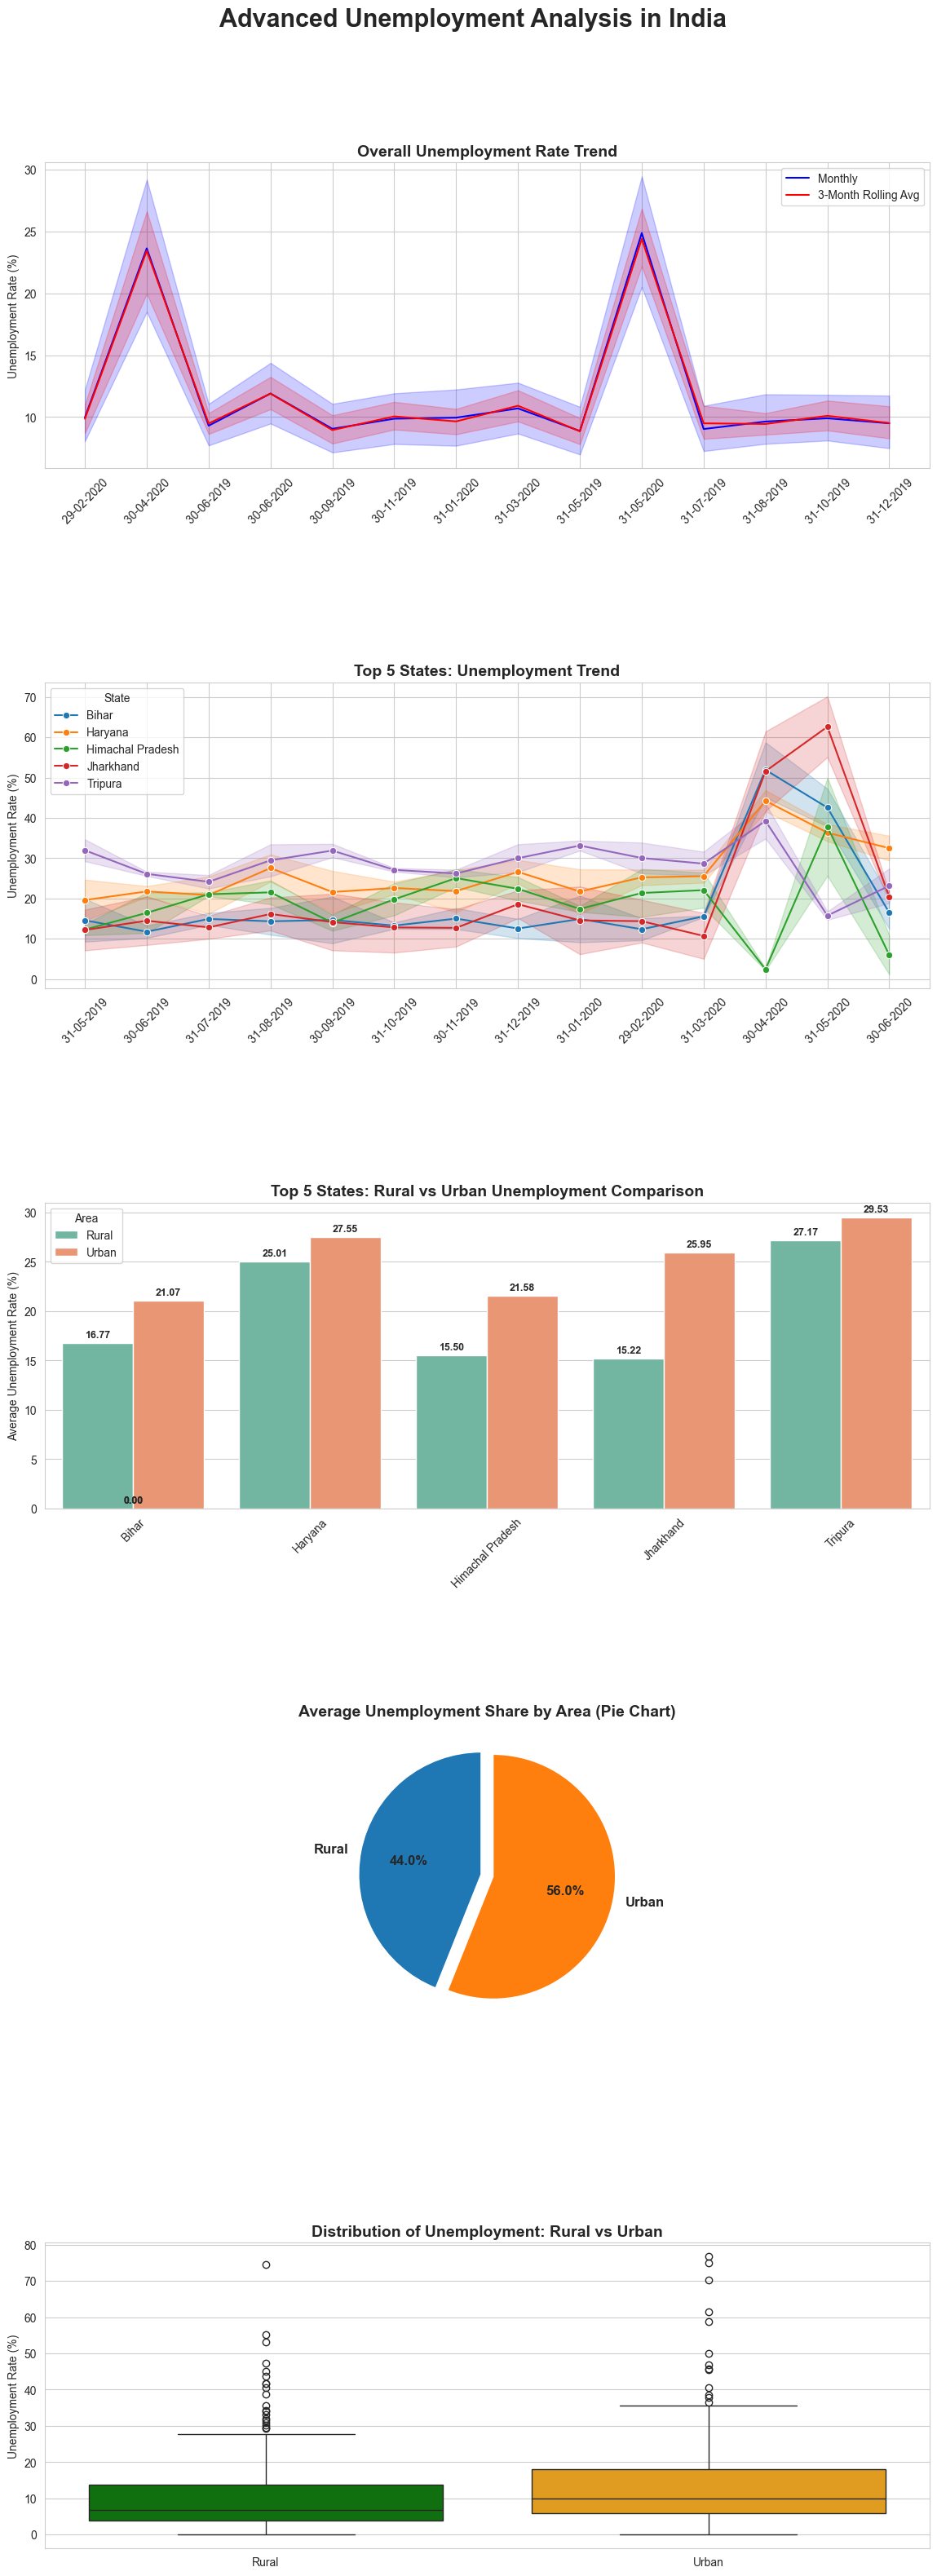

In [14]:
# 2️⃣ Visualization style
sns.set_style("whitegrid")

# 3️⃣ Figure setup
fig, axes = plt.subplots(5, 1, figsize=(14, 38))
plt.subplots_adjust(hspace=0.7)
fig.suptitle("Advanced Unemployment Analysis in India", fontsize=22, fontweight='bold', y=0.93)

# ----------------------------
# 1️⃣ Overall Unemployment Trend
df_sorted = df.sort_values('Date')
df_sorted['Rolling_Unemp'] = df_sorted['Estimated Unemployment Rate (%)'].rolling(window=3).mean()
sns.lineplot(ax=axes[0], x='Date', y='Estimated Unemployment Rate (%)', data=df_sorted, label='Monthly', color='blue')
sns.lineplot(ax=axes[0], x='Date', y='Rolling_Unemp', data=df_sorted, label='3-Month Rolling Avg', color='red')
axes[0].set_title("Overall Unemployment Rate Trend", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Unemployment Rate (%)")
axes[0].set_xlabel("")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# ----------------------------
# 2️⃣ Top 5 States: Unemployment Trend
top5_states = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(5).index
top5_df = df[df['Region'].isin(top5_states)].drop_duplicates(subset=['Region','Area','Date'])
sns.lineplot(ax=axes[1], x='Date', y='Estimated Unemployment Rate (%)', hue='Region', data=top5_df, marker='o')
axes[1].set_title("Top 5 States: Unemployment Trend", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Unemployment Rate (%)")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='State')

# ----------------------------
# 3️⃣ Top 5 States: Rural vs Urban Bar Chart (side-by-side)
bar_df = df[df['Region'].isin(top5_states)].groupby(['Region', 'Area'])['Estimated Unemployment Rate (%)'].mean().reset_index()

sns.barplot(ax=axes[2], data=bar_df, x='Region', y='Estimated Unemployment Rate (%)', hue='Area', palette='Set2')
axes[2].set_title("Top 5 States: Rural vs Urban Unemployment Comparison", fontsize=14, fontweight='bold')
axes[2].set_ylabel("Average Unemployment Rate (%)")
axes[2].set_xlabel("")
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(title='Area')

# Add value labels on top of bars
for p in axes[2].patches:
    axes[2].annotate(f"{p.get_height():.2f}", 
                     (p.get_x() + p.get_width() / 2, p.get_height() + 0.3), 
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

# 4️⃣ Pie Chart: Unemployment Share by Area
area_avg = df.groupby('Area')['Estimated Unemployment Rate (%)'].mean()
colors = ['#1f77b4', '#ff7f0e']
axes[3].pie(area_avg, labels=area_avg.index, autopct='%1.1f%%', colors=colors, 
            startangle=90, explode=(0.05, 0.05), textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[3].set_title("Average Unemployment Share by Area (Pie Chart)", fontsize=14, fontweight='bold')

# ----------------------------
# 5️⃣ Distribution of Unemployment by Area
sns.boxplot(ax=axes[4], x='Area', y='Estimated Unemployment Rate (%)', data=df, palette=['green','orange'])
axes[4].set_title("Distribution of Unemployment: Rural vs Urban", fontsize=14, fontweight='bold')
axes[4].set_xlabel("")
axes[4].set_ylabel("Unemployment Rate (%)")


##### 📊 Chart Descriptions 

1️⃣ Overall Unemployment Rate Trend

This line chart shows the monthly unemployment rate in India from May 2019 to December 2020. The rate remained relatively stable before experiencing a massive, short-lived surge — peaking around 35% in April–May 2020, likely due to the national lockdown during that period.

2️⃣ Top 5 States: Unemployment Trend

This line chart compares the unemployment trends for five states over the same period. All five states show a synchronized and significant spike around April 2020, although the magnitude and recovery rate vary across regions.

3️⃣ Top 5 States: Rural vs Urban Unemployment Comparison

This bar chart compares the average Rural and Urban unemployment rates across five states. In every case, the Urban unemployment rate is notably higher than the Rural rate, with Tripura showing the highest rates overall.

4️⃣ Average Unemployment Share by Area (Pie Chart)

This pie chart illustrates the average share of unemployment between Rural and Urban areas. On average, Urban areas contribute about 56% of total unemployment, while Rural areas account for the remaining 44%, indicating a higher concentration of joblessness in cities.

5️⃣ Distribution of Unemployment: Rural vs Urban

This box plot compares the distribution of unemployment rates between Rural and Urban regions. It reveals that Urban areas have a higher median unemployment rate and a slightly broader interquartile range, suggesting greater variability compared to Rural areas.

##### 💡 Recommendations
1️⃣ Target High-Unemployment States

Prioritize job creation and economic support in states such as Tripura, Jammu & Kashmir, and Haryana, which consistently report higher unemployment levels. Tailored regional programs can help address local economic challenges.

2️⃣ Strengthen Rural Employment Schemes

Expand initiatives like MGNREGA and promote agriculture-linked industries to enhance employment stability in rural areas, particularly during off-season periods or post-disaster recovery phases.

3️⃣ Support Urban Workforce Resilience

Since urban unemployment remains higher overall, promote micro-business incentives, start-up incubation, and digital skill development to boost job opportunities and adaptability in urban centers.

4️⃣ Enhance Data Monitoring and Transparency

Encourage real-time unemployment tracking systems and improved state-level data reporting. Accurate, frequent data collection enables timely intervention and better resource allocation.

5️⃣ Encourage Skill Development and Education Alignment

Invest in vocational training and upskilling programs aligned with local industry needs to bridge the gap between education and employability—especially in high-unemployment states.

6️⃣ Promote Labour Participation

Introduce policies and awareness programs that encourage greater workforce participation, especially among women and young adults, to maintain steady labour force engagement and reduce dependency ratios.

#### Conclusion

The analysis provides a clear picture of India’s unemployment trends between 2019 and 2020, revealing a major disruption during the COVID-19 lockdown period followed by a gradual recovery.
Urban regions consistently faced higher unemployment rates than rural areas, emphasizing the need for targeted urban job policies and sustainable employment strategies.
By leveraging continuous data monitoring, skill development initiatives, and region-specific employment programs, India can strengthen its workforce resilience and reduce unemployment disparities across states.

Exporting Cleaned Dataset

In [15]:
df.to_csv("Cleaned_Unemployment_Analysis_Dataset_of_India.csv", index=False)

print("Dataset successfully exported as 'Cleaned_Unemployment_Analysis_Dataset_of_India.csv'")

Dataset successfully exported as 'Cleaned_Unemployment_Analysis_Dataset_of_India.csv'


## Unemployment Analysis is done succesfully !